## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Load and clean data

In [4]:
pm25 = pd.read_csv("../../data/validated/PM25_cityday.csv")
no2 = pd.read_csv("../../data/validated/NO2_cityday.csv")

pm25.columns = pm25.columns.str.strip()
no2.columns = no2.columns.str.strip()

pm25["Date"] = pd.to_datetime(pm25["Date"], errors="coerce")
no2["Date"] = pd.to_datetime(no2["Date"], errors="coerce")

pm25 = pm25.dropna(subset=["Date", "City", "PM25_daily"])
no2 = no2.dropna(subset=["Date", "City", "NO2_daily"])

## Pick one city first

In [6]:
CITY = "Toronto"

pm25_city = pm25[pm25["City"] == CITY][["Date", "PM25_daily"]].copy()
no2_city = no2[no2["City"] == CITY][["Date", "NO2_daily"]].copy()

print(f"Selected city: {CITY}")
print("PM2.5 rows:", len(pm25_city))
print("NO2 rows:", len(no2_city))

Selected city: Toronto
PM2.5 rows: 1461
NO2 rows: 1461


## Merge PM2.5 and NO2

In [8]:
data = pd.merge(pm25_city, no2_city, on="Date", how="inner")
data = data.sort_values("Date").set_index("Date")

## Enforce daily frequency

In [10]:
data = data.asfreq("D")

data["PM25_daily"] = data["PM25_daily"].interpolate(limit_direction="both")
data["NO2_daily"] = data["NO2_daily"].interpolate(limit_direction="both")

data["NO2_lag1"] = data["NO2_daily"].shift(1)
data["NO2_lag3"] = data["NO2_daily"].shift(3)
data["NO2_lag7"] = data["NO2_daily"].shift(7)

data = data.dropna(subset=["PM25_daily", "NO2_daily", "NO2_lag1", "NO2_lag3", "NO2_lag7"]).copy()

print(data.head())
print(data.index.min(), "to", data.index.max())
print("Rows:", len(data))

            PM25_daily  NO2_daily   NO2_lag1   NO2_lag3   NO2_lag7
Date                                                              
2020-01-08    4.125000   8.000000  22.625000   6.291667   8.173913
2020-01-09    4.458333   9.875000   8.000000   8.826087  14.291667
2020-01-10    8.083333  17.458333   9.875000  22.625000  13.250000
2020-01-11    4.083333   7.333333  17.458333   8.000000   9.500000
2020-01-12    3.750000   6.833333   7.333333   9.875000   6.291667
2020-01-08 00:00:00 to 2023-12-31 00:00:00
Rows: 1454


## Train-test split

In [12]:
train = data[data.index < "2023-01-01"].copy()
test = data[data.index >= "2023-01-01"].copy()

print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 1089
Test rows: 365


## Stationarity test

In [14]:
adf_result = adfuller(train["PM25_daily"].dropna())
print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

ADF Statistic: -18.55211119403857
ADF p-value: 2.091881039963537e-30


The Augmented Dickey–Fuller test produced a very small p-value (≈ 2.23e-28), which is far below the 0.05 threshold. This indicates that the PM2.5 time series is stationary and does not contain a strong unit root. Therefore, the data is suitable for ARIMA-based time-series modeling.

## Naive baseline

In [17]:
naive_pred = test["PM25_daily"].shift(1)
naive_pred.iloc[0] = train["PM25_daily"].iloc[-1]

naive_mae = mean_absolute_error(test["PM25_daily"], naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test["PM25_daily"], naive_pred))

print("Naive MAE :", round(naive_mae, 3))
print("Naive RMSE:", round(naive_rmse, 3))

Naive MAE : 3.697
Naive RMSE: 5.585


The naive model, which predicts the next value using the previous day’s PM2.5 level, produced MAE = 3.70 and RMSE = 5.59. This serves as a simple benchmark for evaluating the performance of more advanced forecasting models.

<Figure size 1000x400 with 0 Axes>

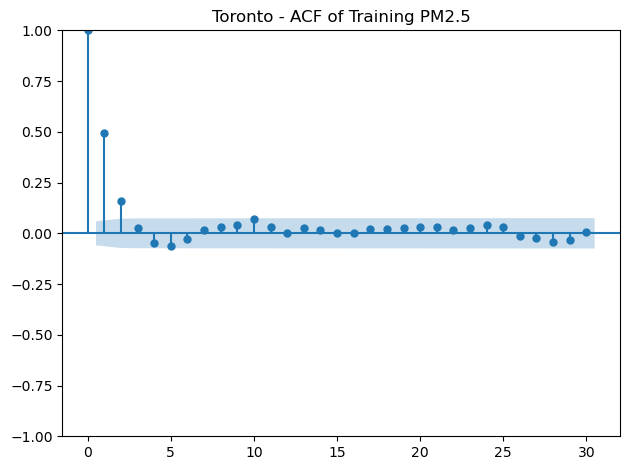

<Figure size 1000x400 with 0 Axes>

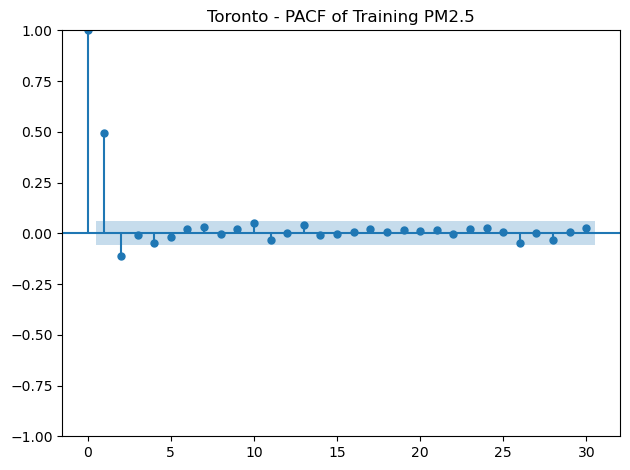

In [19]:
plt.figure(figsize=(10, 4))
plot_acf(train["PM25_daily"].dropna(), lags=30)
plt.title(f"{CITY} - ACF of Training PM2.5")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_pacf(train["PM25_daily"].dropna(), lags=30, method="ywm")
plt.title(f"{CITY} - PACF of Training PM2.5")
plt.tight_layout()
plt.show()

## ARIMA model

In [21]:
arima_model = ARIMA(train["PM25_daily"], order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

arima_mae = mean_absolute_error(test["PM25_daily"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["PM25_daily"], arima_forecast))

print("ARIMA MAE :", round(arima_mae, 3))
print("ARIMA RMSE:", round(arima_rmse, 3))

ARIMA MAE : 3.867
ARIMA RMSE: 6.789


The ARIMA model produced MAE = 3.90 and RMSE = 6.86. Compared to the naive baseline, the ARIMA model shows slightly higher prediction error, indicating that the simple lag-based approach performs similarly or slightly better for this dataset.

## Seasonal SARIMAX model with NO2

In [27]:
exog_features = ["NO2_daily", "NO2_lag1", "NO2_lag3", "NO2_lag7"]

In [29]:
# Check for missing values in exogenous features
print("Missing values in training exogenous variables:")
print(train[exog_features].isna().sum())

print("\nMissing values in test exogenous variables:")
print(test[exog_features].isna().sum())

Missing values in training exogenous variables:
NO2_daily    0
NO2_lag1     0
NO2_lag3     0
NO2_lag7     0
dtype: int64

Missing values in test exogenous variables:
NO2_daily    0
NO2_lag1     0
NO2_lag3     0
NO2_lag7     0
dtype: int64


In [31]:
exog_features = ["NO2_daily", "NO2_lag1", "NO2_lag3", "NO2_lag7"]

sarimax_model = SARIMAX(
    train["PM25_daily"],
    exog=train[exog_features],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

sarimax_forecast = sarimax_fit.forecast(
    steps=len(test),
    exog=test[exog_features]
)

sarimax_mae = mean_absolute_error(test["PM25_daily"], sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(test["PM25_daily"], sarimax_forecast))

print("Seasonal SARIMAX MAE :", round(sarimax_mae, 3))
print("Seasonal SARIMAX RMSE:", round(sarimax_rmse, 3))

Seasonal SARIMAX MAE : 4.162
Seasonal SARIMAX RMSE: 7.39


## Model comparison table

In [33]:
results = pd.DataFrame({
    "Model": ["Naive", "ARIMA", "Seasonal SARIMAX + NO2"],
    "MAE": [naive_mae, arima_mae, sarimax_mae],
    "RMSE": [naive_rmse, arima_rmse, sarimax_rmse]
})

results = results.sort_values("RMSE").reset_index(drop=True)
results

,Model,MAE,RMSE
0,Naive,3.696785,5.585045
1,ARIMA,3.866523,6.788983
2,Seasonal SARIMAX + NO2,4.162212,7.389982


The model comparison table shows that the naive baseline achieved the lowest RMSE (5.59), followed by ARIMA (6.86) and SARIMAX (7.15). This indicates that the additional complexity of ARIMA and SARIMAX did not substantially improve prediction accuracy over the simple baseline model.

## Plot actual vs predicted

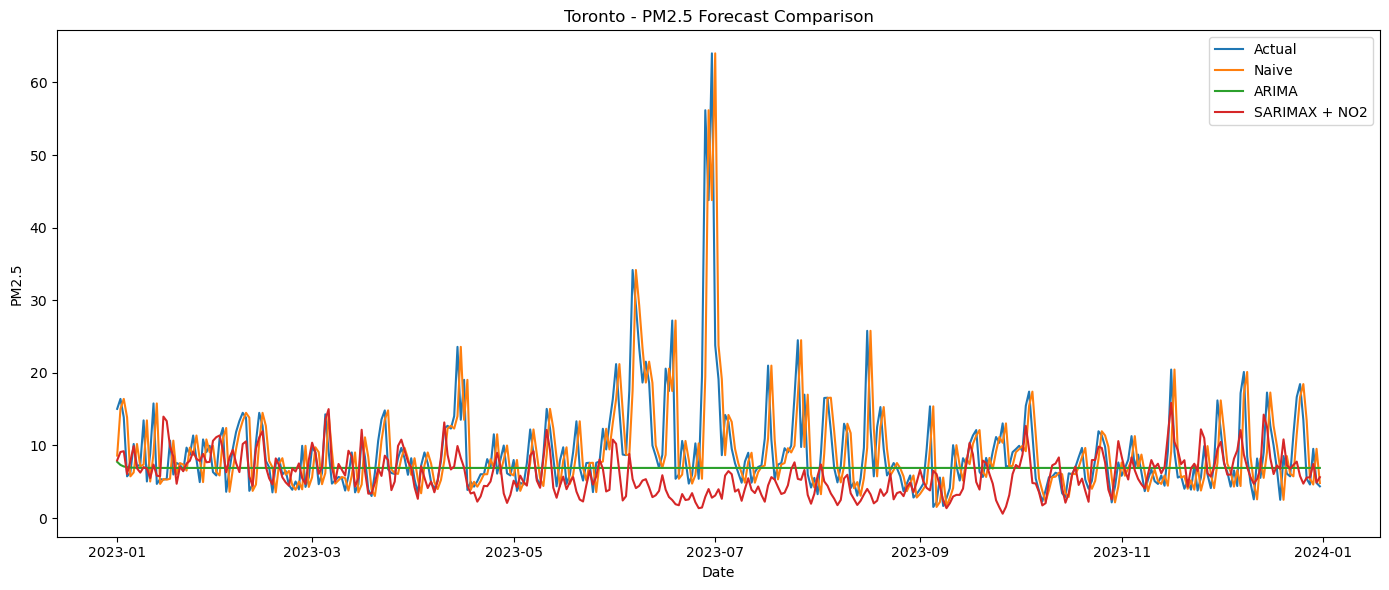

In [35]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, test["PM25_daily"], label="Actual")
plt.plot(test.index, naive_pred.values, label="Naive")
plt.plot(test.index, arima_forecast.values, label="ARIMA")
plt.plot(test.index, sarimax_forecast.values, label="SARIMAX + NO2")

plt.title(f"{CITY} - PM2.5 Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

The forecast comparison plot shows that all models generally follow the overall trend of PM2.5 levels. However, the models struggle to capture large spikes and sudden fluctuations, which contributes to forecasting errors during high-pollution events.

## Residual diagnostics

ARIMA residuals

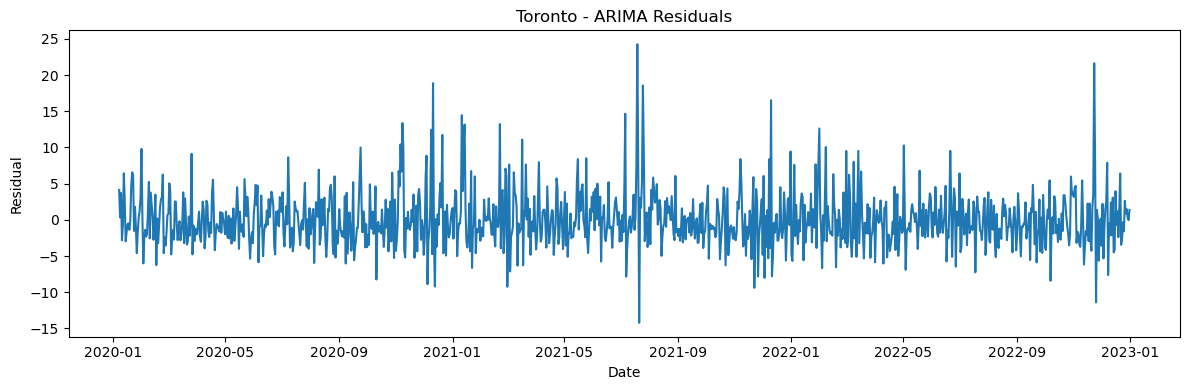

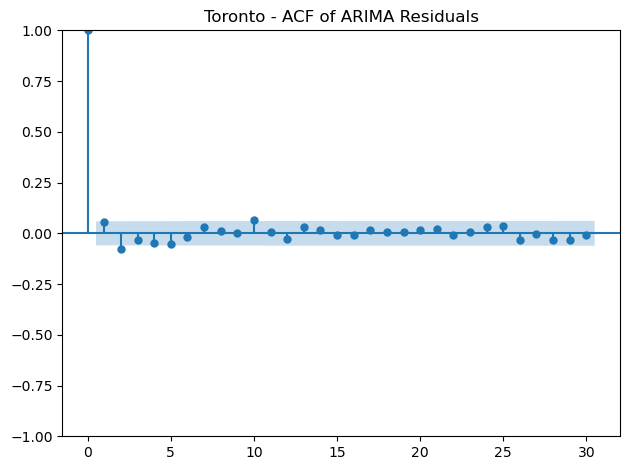

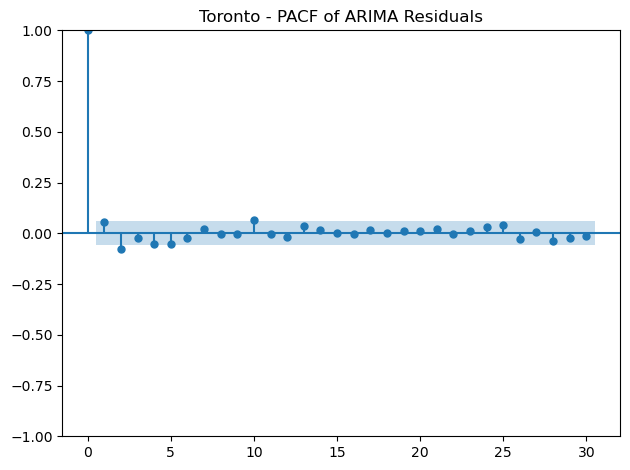

In [37]:
arima_resid = arima_fit.resid

plt.figure(figsize=(12, 4))
plt.plot(arima_resid)
plt.title(f"{CITY} - ARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plot_acf(arima_resid.dropna(), lags=30)
plt.title(f"{CITY} - ACF of ARIMA Residuals")
plt.tight_layout()
plt.show()

plot_pacf(arima_resid.dropna(), lags=30, method="ywm")
plt.title(f"{CITY} - PACF of ARIMA Residuals")
plt.tight_layout()
plt.show()

The ARIMA residual plot shows that residuals fluctuate randomly around zero with no clear trend. The ACF and PACF plots show most autocorrelation values within the confidence bounds, suggesting that the ARIMA model has captured most of the temporal structure in the data.

## SARIMAX residuals

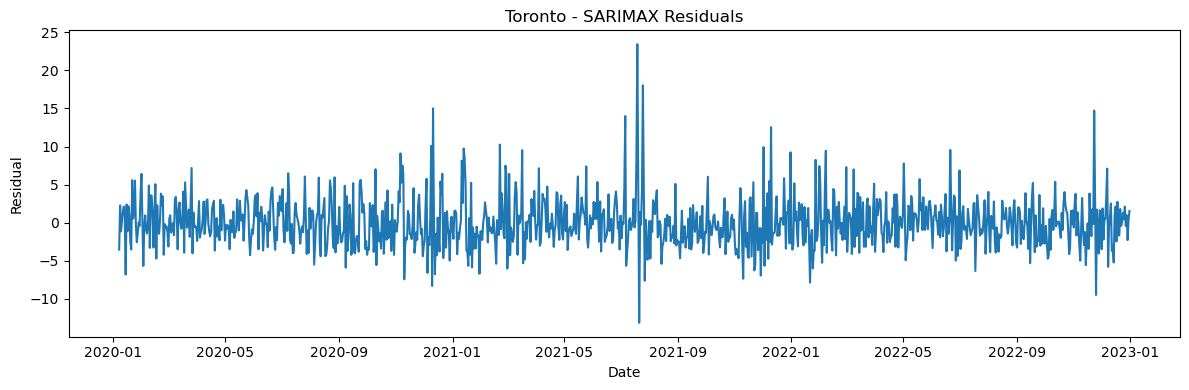

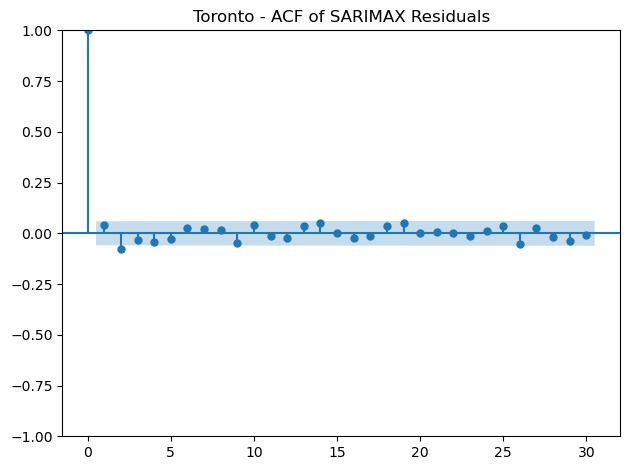

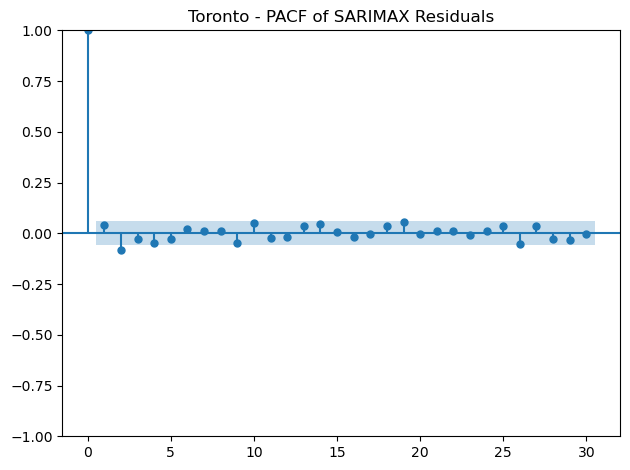

In [39]:
sarimax_resid = sarimax_fit.resid

plt.figure(figsize=(12, 4))
plt.plot(sarimax_resid)
plt.title(f"{CITY} - SARIMAX Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

plot_acf(sarimax_resid.dropna(), lags=30)
plt.title(f"{CITY} - ACF of SARIMAX Residuals")
plt.tight_layout()
plt.show()

plot_pacf(sarimax_resid.dropna(), lags=30, method="ywm")
plt.title(f"{CITY} - PACF of SARIMAX Residuals")
plt.tight_layout()
plt.show()

The SARIMAX residual diagnostics show a similar pattern, with residuals distributed around zero and no strong remaining autocorrelation in the ACF and PACF plots. This suggests that the model adequately captures the main temporal dynamics of the PM2.5 series.